# 🌳 Árbol de Regresión — Predicción de Nivel de Estrés
**Dataset:** Teen Mental Health Dataset (1,200 muestras | 13 variables)  
**Variable objetivo:** `stress_level` (valor numérico continuo de 1 a 10)  
**Estructura:** Igual al notebook de Boston Housing, adaptado a datos de salud mental adolescente

## 📦 1. Librerías

In [ ]:
# ── Librerías ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,    # MAE  → error promedio en las mismas unidades
    mean_squared_error,     # MSE  → penaliza más los errores grandes
    r2_score                # R²   → qué % de la varianza explica el modelo
)

## 📂 2. Cargar y explorar el dataset
> **Subir el archivo:** en Colab, ejecuta la celda de abajo para subir `datosestresyansiedad.xlsx`

In [ ]:
# ── Cargar dataset ────────────────────────────────────────────────────────────
# Teen Mental Health Dataset: predice el nivel de estrés (stress_level)
# 1200 muestras | 13 variables (edad, género, horas en redes sociales, etc.)
datos = pd.read_excel('datosestresyansiedad.xlsx')

print('Forma del dataset:', datos.shape)
print('\nColumnas:', list(datos.columns))
datos

Forma del dataset: (1200, 13)

Columnas: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'anxiety_level', 'addiction_level', 'depression_label', 'stress_level']


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,anxiety_level,addiction_level,depression_label,stress_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,1,0,2
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,1,10,0,8
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,4,2,0,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,7,9,0,1
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,5,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,4,4,0,3
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,4,4,0,7
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,0,1
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,9,9,0,7


## 🔧 3. Preprocesamiento — Codificar variables categóricas

In [ ]:
# ── Codificar variables categóricas ──────────────────────────────────────────
# gender: male / female → 0 / 1
datos['gender_encoded'] = datos['gender'].astype('category').cat.codes

# platform_usage: Instagram / TikTok / Both → 0 / 1 / 2
datos['platform_encoded'] = datos['platform_usage'].astype('category').cat.codes

# social_interaction_level: low / medium / high → 0 / 1 / 2
datos['social_encoded'] = datos['social_interaction_level'].astype('category').cat.codes

# Mostrar el mapeo para entender los códigos
print('gender:', dict(enumerate(datos['gender'].astype('category').cat.categories)))
print('platform_usage:', dict(enumerate(datos['platform_usage'].astype('category').cat.categories)))
print('social_interaction_level:', dict(enumerate(datos['social_interaction_level'].astype('category').cat.categories)))

gender: {0: 'female', 1: 'male'}
platform_usage: {0: 'Both', 1: 'Instagram', 2: 'TikTok'}
social_interaction_level: {0: 'high', 1: 'low', 2: 'medium'}


## 🎯 4. Definir X (características) e y (variable objetivo)

In [ ]:
# ── Seleccionar features y target ────────────────────────────────────────────
# Eliminamos las columnas originales categóricas y usamos las codificadas
# También eliminamos anxiety_level y depression_label para no "hacer trampa"
# (son variables muy correlacionadas con el estrés; en un modelo real se evalúa su uso)

columnas_excluir = ['gender', 'platform_usage', 'social_interaction_level',
                    'stress_level']

X = datos.drop(columns=columnas_excluir)
y = datos['stress_level'].rename('NivelEstres')   # Variable CUANTITATIVA (1-10)

print('Forma de X:', X.shape)
print('Rango de y:', y.min(), '→', y.max())
print('\nFeatures usadas:', list(X.columns))
print('\nPrimeras filas:')
print(X.head(3))
print(y.head(3))

Forma de X: (1200, 12)
Rango de y: 1 → 10

Features usadas: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label', 'gender_encoded', 'platform_encoded', 'social_encoded']

Primeras filas:
   age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0   14                       7.9          7.4                       2.9   
1   19                       1.9          8.0                       2.9   
2   17                       1.3          7.6                       0.5   

   academic_performance  physical_activity  anxiety_level  addiction_level  \
0                  3.01                1.5              2                1   
1                  3.22                0.8              1               10   
2                  3.92                0.0              4                2   

   depression_label  gender_encoded  platform_encoded  social_encoded  
0

## ✂️ 5. División 80% entrenamiento / 20% prueba

In [ ]:
# ── Split 80% / 20% ───────────────────────────────────────────────────────────
# En regresión NO se usa stratify (es para clasificación)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Entrenamiento:', X_train.shape)   # ~960 muestras
print('Prueba:       ', X_test.shape)    # ~240 muestras

Entrenamiento: (960, 12)
Prueba:        (240, 12)


## 🌳 6. Entrenar el Árbol de Regresión

In [ ]:
# ── DecisionTreeRegressor (NO Classifier) ────────────────────────────────────
# criterion='squared_error' → minimiza el MSE en cada división
# max_depth=5               → controla la complejidad; más profundo = más sobreajuste
# min_samples_split=20      → un nodo necesita al menos 20 muestras para dividirse
# min_samples_leaf=10       → cada hoja debe tener al menos 10 muestras
# random_state=42           → reproducibilidad

arbol_reg = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# ── Entrenar ──────────────────────────────────────────────────────────────────
arbol_reg.fit(X_train, y_train)

print('Profundidad real:', arbol_reg.get_depth())
print('Número de hojas: ', arbol_reg.get_n_leaves())

Profundidad real: 5
Número de hojas:  17


## 🔮 7. Predicciones

In [ ]:
# ── Predecir valores numéricos continuos ─────────────────────────────────────
# predict() devuelve el PROMEDIO de y_train de las muestras en cada hoja
y_pred = arbol_reg.predict(X_test)

In [ ]:
# ── Ver comparación real vs predicho ─────────────────────────────────────────
comparacion = pd.DataFrame({
    'Real'    : y_test.values[:10],
    'Predicho': y_pred[:10].round(4),
    'Error'   : (y_test.values[:10] - y_pred[:10]).round(4)
})

print('\nComparación Real vs Predicho (primeras 10 muestras):')
print(comparacion.to_string(index=False))


Comparación Real vs Predicho (primeras 10 muestras):
 Real  Predicho   Error
    8    4.4298  3.5702
    7    4.4298  2.5702
    2    5.7348 -3.7348
    4    5.5686 -1.5686
    4    8.9000 -4.9000
    6    4.4298  1.5702
    8    7.0000  1.0000
    8    5.7348  2.2652
    6    4.8317  1.1683
    4    5.7348 -1.7348


## 📊 8. Métricas de regresión

In [ ]:
# ── Métricas de regresión ─────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('        MÉTRICAS DE REGRESIÓN')
print('=' * 45)
print(f'  MAE  (Error Absoluto Medio)  : {mae:.4f}')
print(f'  MSE  (Error Cuadrático Medio): {mse:.4f}')
print(f'  RMSE (Raíz del MSE)          : {rmse:.4f}')
print(f'  R²   (Coef. Determinación)   : {r2:.4f}  →  {r2*100:.2f}%')
print('=' * 45)

# ── Interpretación rápida ─────────────────────────────────────────────────────
# MAE  → en promedio el modelo se equivoca en MAE puntos de estrés
# RMSE → igual que MAE pero penaliza errores grandes
# R²   → el modelo explica el X% de la variabilidad del nivel de estrés

        MÉTRICAS DE REGRESIÓN
  MAE  (Error Absoluto Medio)  : 2.4761
  MSE  (Error Cuadrático Medio): 8.5727
  RMSE (Raíz del MSE)          : 2.9279
  R²   (Coef. Determinación)   : -0.1056  →  -10.56%


## 📈 9. Gráfica: Predicciones vs Variable

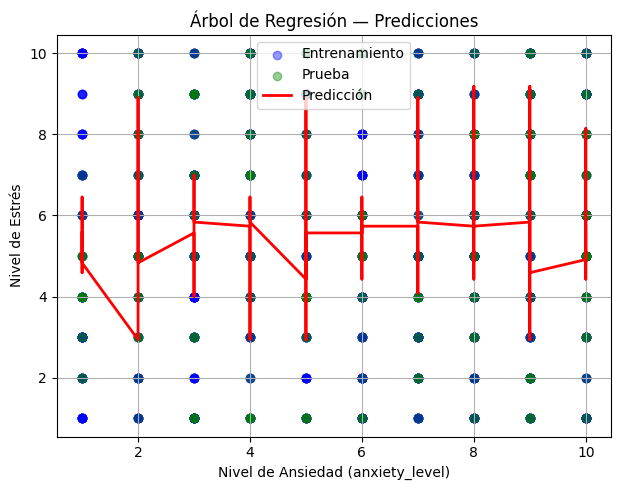

In [ ]:
plt.figure(figsize=(12, 5))

# Ordenar por anxiety_level para línea de predicción más suave
combined_test = pd.DataFrame({
    'anxiety_level': X_test['anxiety_level'],
    'y_test'       : y_test,
    'y_pred'       : y_pred
})
combined_sorted = combined_test.sort_values(by='anxiety_level')

plt.subplot(1, 2, 1)
plt.scatter(X_train['anxiety_level'], y_train,
            color='blue', alpha=0.4, label='Entrenamiento')
plt.scatter(X_test['anxiety_level'], y_test,
            color='green', alpha=0.4, label='Prueba')
plt.plot(combined_sorted['anxiety_level'], combined_sorted['y_pred'],
         color='red', linewidth=2, label='Predicción')
plt.xlabel('Nivel de Ansiedad (anxiety_level)')
plt.ylabel('Nivel de Estrés')
plt.title('Árbol de Regresión — Predicciones')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 📉 10. Evaluación visual: Real vs Predicho y Residuos

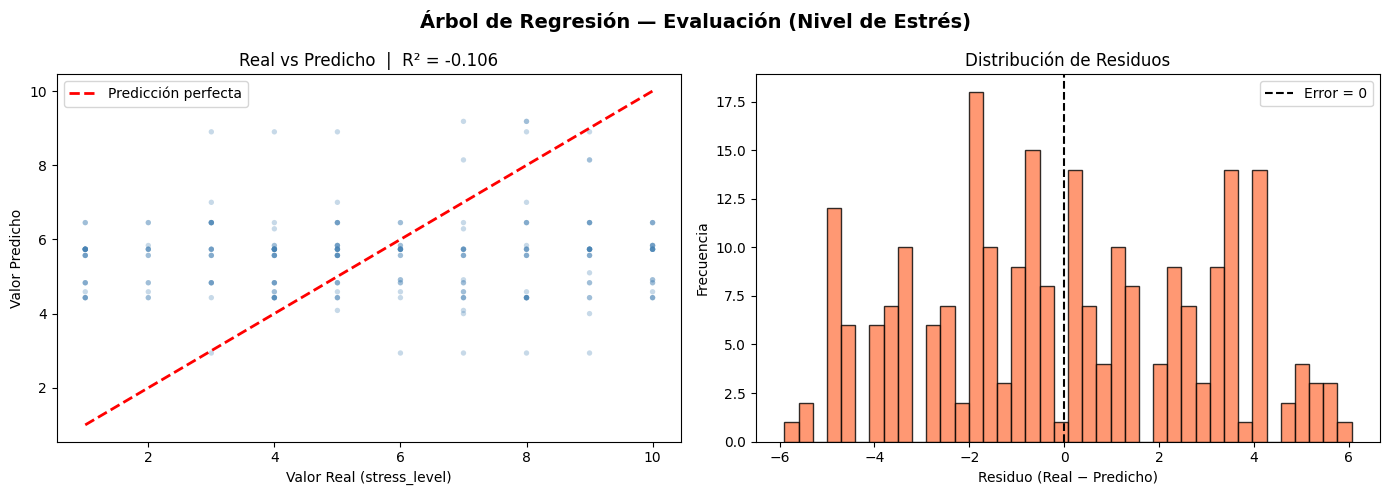

In [ ]:
# ── Scatter plot: si el modelo fuera perfecto, todos los puntos
#    estarían sobre la línea diagonal roja ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Real vs Predicho ───────────────────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue',
                edgecolors='none', s=15)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Predicción perfecta'
)
axes[0].set_xlabel('Valor Real (stress_level)')
axes[0].set_ylabel('Valor Predicho')
axes[0].set_title(f'Real vs Predicho  |  R² = {r2:.3f}')
axes[0].legend()

# ── Gráfico 2: Distribución de residuos ──────────────────────────────────────
# Residuo = Real - Predicho
# Un buen modelo tiene residuos centrados en 0 y distribuidos simétricamente
residuos = y_test.values - y_pred

axes[1].hist(residuos, bins=40, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Error = 0')
axes[1].set_xlabel('Residuo (Real − Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()

plt.suptitle('Árbol de Regresión — Evaluación (Nivel de Estrés)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌲 11. Visualización gráfica del árbol

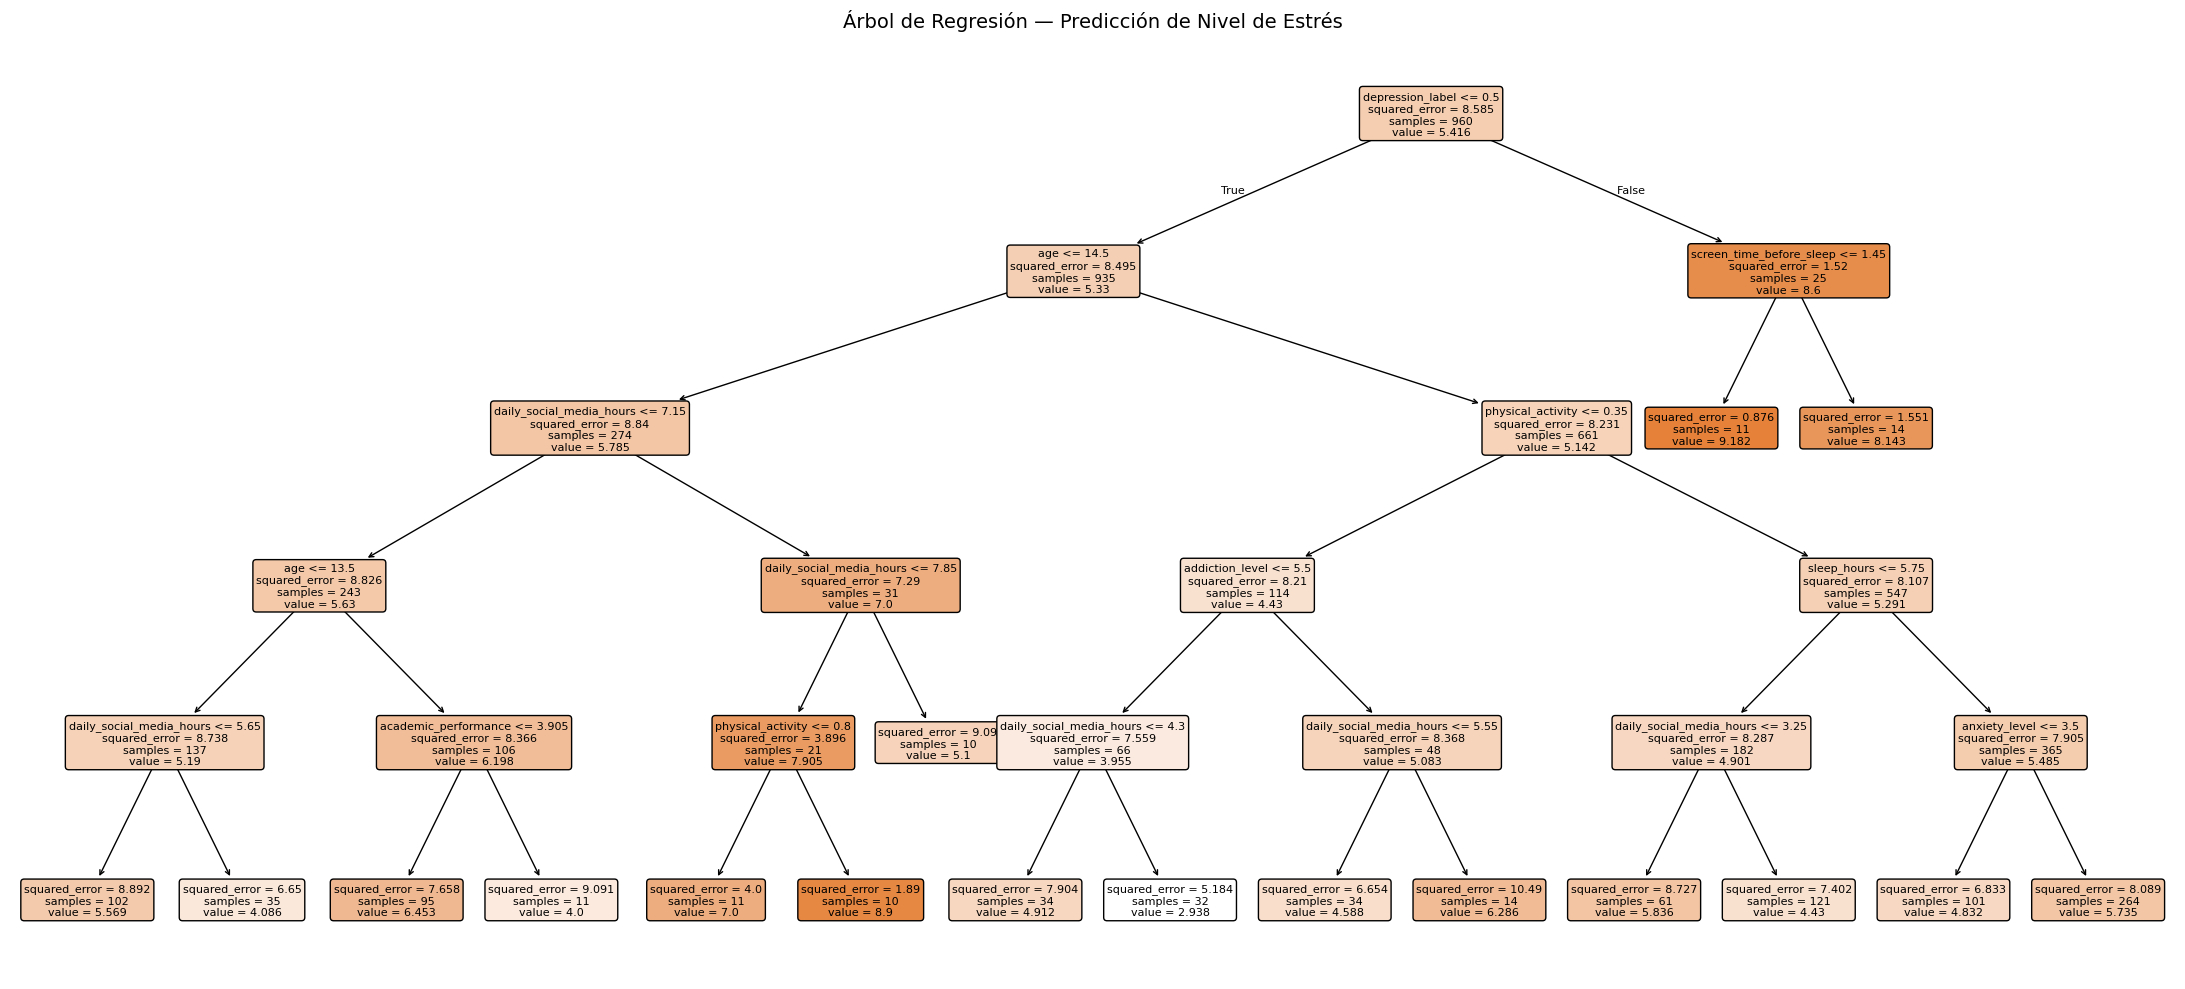


Reglas del árbol (primeras 60 líneas):
|--- depression_label <= 0.50
|   |--- age <= 14.50
|   |   |--- daily_social_media_hours <= 7.15
|   |   |   |--- age <= 13.50
|   |   |   |   |--- daily_social_media_hours <= 5.65
|   |   |   |   |   |--- value: [5.57]
|   |   |   |   |--- daily_social_media_hours >  5.65
|   |   |   |   |   |--- value: [4.09]
|   |   |   |--- age >  13.50
|   |   |   |   |--- academic_performance <= 3.91
|   |   |   |   |   |--- value: [6.45]
|   |   |   |   |--- academic_performance >  3.91
|   |   |   |   |   |--- value: [4.00]
|   |   |--- daily_social_media_hours >  7.15
|   |   |   |--- daily_social_media_hours <= 7.85
|   |   |   |   |--- physical_activity <= 0.80
|   |   |   |   |   |--- value: [7.00]
|   |   |   |   |--- physical_activity >  0.80
|   |   |   |   |   |--- value: [8.90]
|   |   |   |--- daily_social_media_hours >  7.85
|   |   |   |   |--- value: [5.10]
|   |--- age >  14.50
|   |   |--- physical_activity <= 0.35
|   |   |   |--- addicti

In [ ]:
# ── Visualización gráfica ─────────────────────────────────────────────────────
# En cada nodo se muestra:
#   - La condición de división (ej: anxiety_level <= 5.5)
#   - squared_error → MSE del nodo
#   - samples       → cuántas muestras cayeron aquí
#   - value         → PROMEDIO de stress_level en ese nodo (la predicción)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    arbol_reg,
    feature_names=X.columns,
    filled=True,      # Color más intenso = valor promedio más alto
    rounded=True,
    fontsize=8,
    ax=ax,
    precision=3
)
ax.set_title('Árbol de Regresión — Predicción de Nivel de Estrés',
             fontsize=14)
plt.tight_layout()
plt.show()

# ── Versión texto ─────────────────────────────────────────────────────────────
reglas = export_text(arbol_reg, feature_names=list(X.columns))
print('\nReglas del árbol (primeras 60 líneas):')
print('\n'.join(reglas.split('\n')[:60]))

## 🏆 12. Importancia de características


Importancia de características:
          Característica  Importancia
daily_social_media_hours     0.326309
        depression_label     0.253337
                     age     0.136959
       physical_activity     0.086450
           anxiety_level     0.057999
    academic_performance     0.057720
             sleep_hours     0.040291
         addiction_level     0.034463
screen_time_before_sleep     0.006472
          gender_encoded     0.000000
        platform_encoded     0.000000
          social_encoded     0.000000


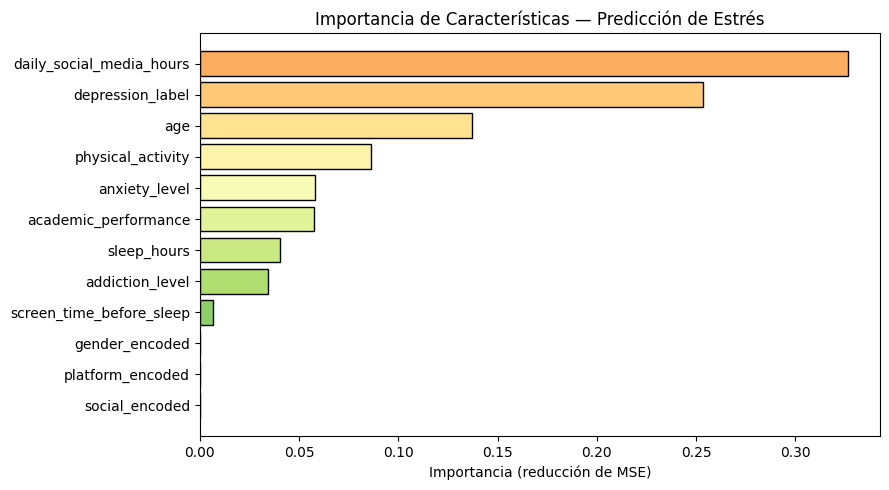

In [ ]:
# ── Qué variables influyen más en predecir el nivel de estrés ─────────────────
importancias = arbol_reg.feature_importances_

df_imp = pd.DataFrame({
    'Característica': X.columns,
    'Importancia'   : importancias
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print('\nImportancia de características:')
print(df_imp.to_string(index=False))

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colores = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_imp)))
ax.barh(df_imp['Característica'], df_imp['Importancia'],
        color=colores, edgecolor='black')
ax.set_xlabel('Importancia (reducción de MSE)')
ax.set_title('Importancia de Características — Predicción de Estrés')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 🧑 13. Predecir el estrés de un adolescente nuevo

In [ ]:
# ── Predecir el estrés de un adolescente con características específicas ───────
# Orden de columnas: age, daily_social_media_hours, sleep_hours,
#                    screen_time_before_sleep, academic_performance,
#                    physical_activity, anxiety_level, addiction_level,
#                    depression_label, gender_encoded, platform_encoded, social_encoded

nueva_muestra = pd.DataFrame([{
    'age'                     : 16,
    'daily_social_media_hours': 5.0,
    'sleep_hours'             : 6.5,
    'screen_time_before_sleep': 2.0,
    'academic_performance'    : 3.0,
    'physical_activity'       : 1.0,
    'anxiety_level'           : 6,
    'addiction_level'         : 5,
    'depression_label'        : 0,
    'gender_encoded'          : 1,   # 1 = male (ver mapeo del paso 3)
    'platform_encoded'        : 0,   # 0 = Both
    'social_encoded'          : 1,   # 1 = medium
}])

estres_predicho = arbol_reg.predict(nueva_muestra)

print('\nCaracterísticas del adolescente:')
for col, val in zip(nueva_muestra.columns, nueva_muestra.values[0]):
    print(f'  {col:30s}: {val}')

print(f'\nNivel de estrés predicho: {estres_predicho[0]:.2f} / 10')


Características del adolescente:
  age                           : 16.0
  daily_social_media_hours      : 5.0
  sleep_hours                   : 6.5
  screen_time_before_sleep      : 2.0
  academic_performance          : 3.0
  physical_activity             : 1.0
  anxiety_level                 : 6.0
  addiction_level               : 5.0
  depression_label              : 0.0
  gender_encoded                : 1.0
  platform_encoded              : 0.0
  social_encoded                : 1.0

Nivel de estrés predicho: 5.73 / 10


---
## ⚙️ OPTIMIZANDO EL ÁRBOL

## 🔍 14. Librerías de optimización

In [ ]:
# ── Librerías adicionales para optimización ───────────────────────────────────
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    validation_curve,
    learning_curve
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (960, 12) | Test: (240, 12)


## 📉 15. Árbol base (sin optimizar)

In [ ]:
# ── Árbol sin ningún control de hiperparámetros ───────────────────────────────
# Esto nos da el "peor caso" para comparar después de optimizar

arbol_base = DecisionTreeRegressor(random_state=42)
arbol_base.fit(X_train, y_train)
y_pred_base = arbol_base.predict(X_test)

r2_base   = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)

print('=' * 45)
print('  ÁRBOL BASE (sin optimizar)')
print('=' * 45)
print(f'  R²   : {r2_base:.4f}')
print(f'  RMSE : {rmse_base:.4f}')
print(f'  MAE  : {mae_base:.4f}')
print(f'  Profundidad: {arbol_base.get_depth()}')
print(f'  Hojas      : {arbol_base.get_n_leaves()}')

  ÁRBOL BASE (sin optimizar)
  R²   : -1.3107
  RMSE : 4.2328
  MAE  : 3.5083
  Profundidad: 21
  Hojas      : 663


## 🔄 16. Validación cruzada (cross_val_score)

In [ ]:
# ── cross_val_score evalúa el modelo con K particiones del train ──────────────
# cv=5   → divide X_train en 5 partes; entrena en 4 y valida en 1, rotando
# El resultado es el R² promedio de los 5 folds → estimación honesta

arbol_cv = DecisionTreeRegressor(max_depth=5, random_state=42)

scores_r2 = cross_val_score(
    arbol_cv, X_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

scores_rmse = cross_val_score(
    arbol_cv, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print('\nValidación Cruzada (5 folds) — max_depth=5:')
print(f'  R²   por fold : {scores_r2.round(4)}')
print(f'  R²   promedio : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
print(f'  RMSE promedio : {(-scores_rmse).mean():.4f} ± {scores_rmse.std():.4f}')


Validación Cruzada (5 folds) — max_depth=5:
  R²   por fold : [-0.0674 -0.1546 -0.0242 -0.2029 -0.098 ]
  R²   promedio : -0.1094 ± 0.0631
  RMSE promedio : 3.0779 ± 0.1265


## 📊 17. Curva de validación — max_depth

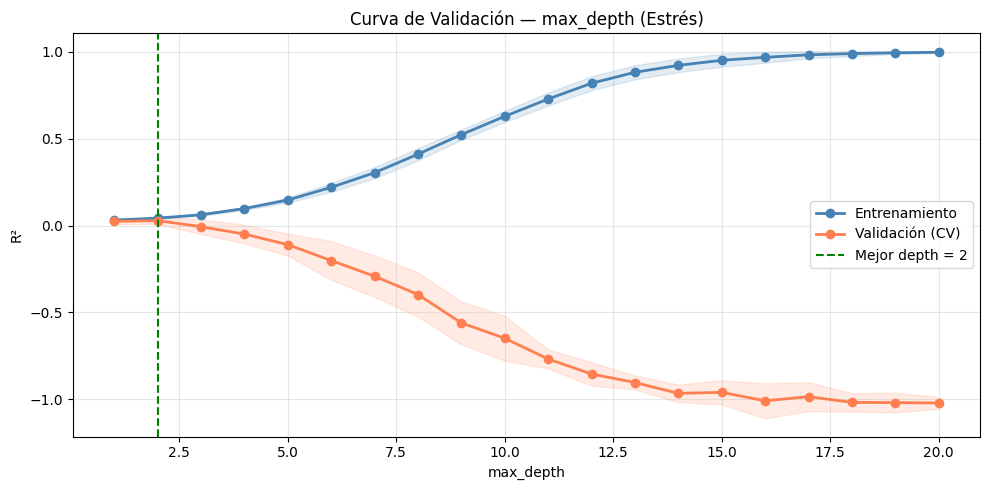


Mejor max_depth según curva de validación: 2
R² validación en ese punto: 0.0289


In [ ]:
# ── Curva de validación para max_depth ────────────────────────────────────────
profundidades = np.arange(1, 21)   # Probar profundidades del 1 al 20

train_scores, val_scores = validation_curve(
    DecisionTreeRegressor(random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=profundidades,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profundidades, train_mean, 'o-', color='steelblue',
        label='Entrenamiento', linewidth=2)
ax.fill_between(profundidades,
                train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='steelblue')

ax.plot(profundidades, val_mean, 'o-', color='coral',
        label='Validación (CV)', linewidth=2)
ax.fill_between(profundidades,
                val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='coral')

mejor_depth = profundidades[np.argmax(val_mean)]
ax.axvline(mejor_depth, color='green', linestyle='--', linewidth=1.5,
           label=f'Mejor depth = {mejor_depth}')

ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.set_title('Curva de Validación — max_depth (Estrés)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMejor max_depth según curva de validación: {mejor_depth}')
print(f'R² validación en ese punto: {val_mean[mejor_depth-1]:.4f}')

## 🔬 18. GridSearchCV — búsqueda exhaustiva de hiperparámetros

In [ ]:
# ── Definir la grid de hiperparámetros a explorar ────────────────────────────
# GridSearch prueba TODAS las combinaciones: 5×3×3×3 = 135 combinaciones
# Con cv=5 → entrena 135 × 5 = 675 veces en total

param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'max_features'     : ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(criterion='squared_error', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nMejores hiperparámetros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'  {param:20s}: {valor}')
print(f'\nMejor R² en validación cruzada: {grid_search.best_score_:.4f}')

# ── Evaluar el mejor árbol en el set de prueba ────────────────────────────────
mejor_arbol = grid_search.best_estimator_
y_pred_opt = mejor_arbol.predict(X_test)

r2_opt   = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
mae_opt  = mean_absolute_error(y_test, y_pred_opt)

print('\n' + '=' * 45)
print('  COMPARACIÓN BASE vs OPTIMIZADO')
print('=' * 45)
print(f'  Métrica  | Base     | Optimizado')
print(f'  R²       | {r2_base:.4f}  | {r2_opt:.4f}')
print(f'  RMSE     | {rmse_base:.4f}  | {rmse_opt:.4f}')
print(f'  MAE      | {mae_base:.4f}  | {mae_opt:.4f}')
print('=' * 45)

Fitting 5 folds for each of 135 candidates, totalling 675 fits

Mejores hiperparámetros encontrados:
  max_depth           : 3
  max_features        : sqrt
  min_samples_leaf    : 5
  min_samples_split   : 20

Mejor R² en validación cruzada: 0.0039

  COMPARACIÓN BASE vs OPTIMIZADO
  Métrica  | Base     | Optimizado
  R²       | -1.3107  | -0.0027
  RMSE     | 4.2328  | 2.7883
  MAE      | 3.5083  | 2.3516


## 🎲 19. RandomizedSearchCV — búsqueda aleatoria de hiperparámetros

In [ ]:
# ── RandomizedSearch es ideal cuando la grilla es muy grande ─────────────────
# n_iter=80 → prueba solo 80 combinaciones aleatorias (no todas las posibles)
# Útil cuando tienes muchos hiperparámetros o rangos continuos

from scipy.stats import randint, uniform

param_dist = {
    'max_depth'           : randint(2, 15),         # entero aleatorio entre 2 y 14
    'min_samples_split'   : randint(5, 100),         # entero aleatorio entre 5 y 99
    'min_samples_leaf'    : randint(2, 50),           # entero aleatorio entre 2 y 49
    'max_features'        : [None, 'sqrt', 'log2'],
    'min_impurity_decrease': uniform(0.0, 0.01)      # float aleatorio entre 0 y 0.01
    # min_impurity_decrease → solo divide si la mejora supera este umbral
}

arbol_rand = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=arbol_rand,
    param_distributions=param_dist,
    n_iter=80,                               # 80 combinaciones aleatorias
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train, y_train)

print('\n' + '=' * 50)
print('  RESULTADOS RANDOMIZEDSEARCHCV')
print('=' * 50)
print(f'  Mejores parámetros : {random_search.best_params_}')
print(f'  Mejor RMSE (CV)    : {-random_search.best_score_:.4f}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

  RESULTADOS RANDOMIZEDSEARCHCV
  Mejores parámetros : {'max_depth': 2, 'max_features': None, 'min_impurity_decrease': np.float64(0.0032078006497173583), 'min_samples_leaf': 7, 'min_samples_split': 84}
  Mejor RMSE (CV)    : 2.8794


## 📋 20. Tabla comparativa: Base vs GridSearch vs RandomizedSearch

In [ ]:
# ── Extraer el mejor estimador de cada búsqueda ───────────────────────────────
mejor_grid   = grid_search.best_estimator_
mejor_random = random_search.best_estimator_

# ── Predicciones en test ──────────────────────────────────────────────────────
y_pred_grid   = mejor_grid.predict(X_test)
y_pred_random = mejor_random.predict(X_test)

# ── Función de métricas inline ────────────────────────────────────────────────
def metricas(y_real, y_pred):
    return {
        'R²'  : round(r2_score(y_real, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_real, y_pred)), 4),
        'MAE' : round(mean_absolute_error(y_real, y_pred), 4)
    }

m_base   = metricas(y_test, y_pred_base)
m_grid   = metricas(y_test, y_pred_grid)
m_random = metricas(y_test, y_pred_random)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_resultados = pd.DataFrame(
    [m_base, m_grid, m_random],
    index=['Base (sin optimizar)', 'GridSearchCV', 'RandomizedSearchCV']
)

print('\n' + '=' * 55)
print('       COMPARACIÓN FINAL EN DATOS DE TEST (Estrés)')
print('=' * 55)
print(df_resultados.to_string())
print('=' * 55)
print('↑ R² más alto = mejor  |  ↓ RMSE y MAE más bajos = mejor')


       COMPARACIÓN FINAL EN DATOS DE TEST (Estrés)
                          R²    RMSE     MAE
Base (sin optimizar) -1.3107  4.2328  3.5083
GridSearchCV         -0.0027  2.7883  2.3516
RandomizedSearchCV   -0.0004  2.7851  2.3567
↑ R² más alto = mejor  |  ↓ RMSE y MAE más bajos = mejor


## 📈 21. Curva de aprendizaje — ¿mejora con más datos?

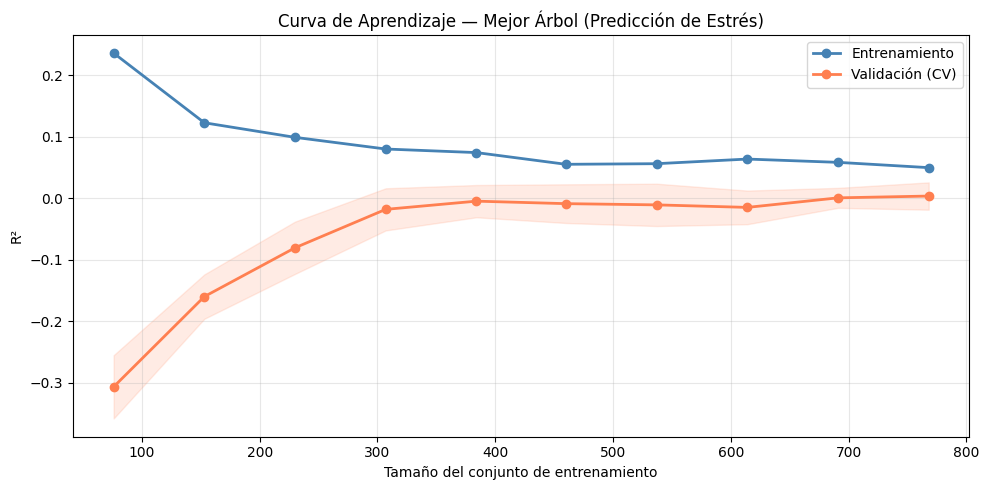

In [ ]:
# ── La curva de aprendizaje muestra si el modelo mejora con más datos ─────────
# Si train y val convergen en un valor alto → modelo bien ajustado
# Si val sigue subiendo al final → más datos ayudarían
# Si hay gran brecha entre train y val → sobreajuste

train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    mejor_grid,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),   # del 10% al 100% del train
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lc_train_mean = train_scores_lc.mean(axis=1)
lc_val_mean   = val_scores_lc.mean(axis=1)
lc_val_std    = val_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, lc_train_mean, 'o-', color='steelblue',
        label='Entrenamiento', linewidth=2)
ax.plot(train_sizes, lc_val_mean,   'o-', color='coral',
        label='Validación (CV)', linewidth=2)
ax.fill_between(train_sizes,
                lc_val_mean - lc_val_std,
                lc_val_mean + lc_val_std, alpha=0.15, color='coral')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.set_title('Curva de Aprendizaje — Mejor Árbol (Predicción de Estrés)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🖼️ 22. Comparación visual: Real vs Predicho (3 modelos)

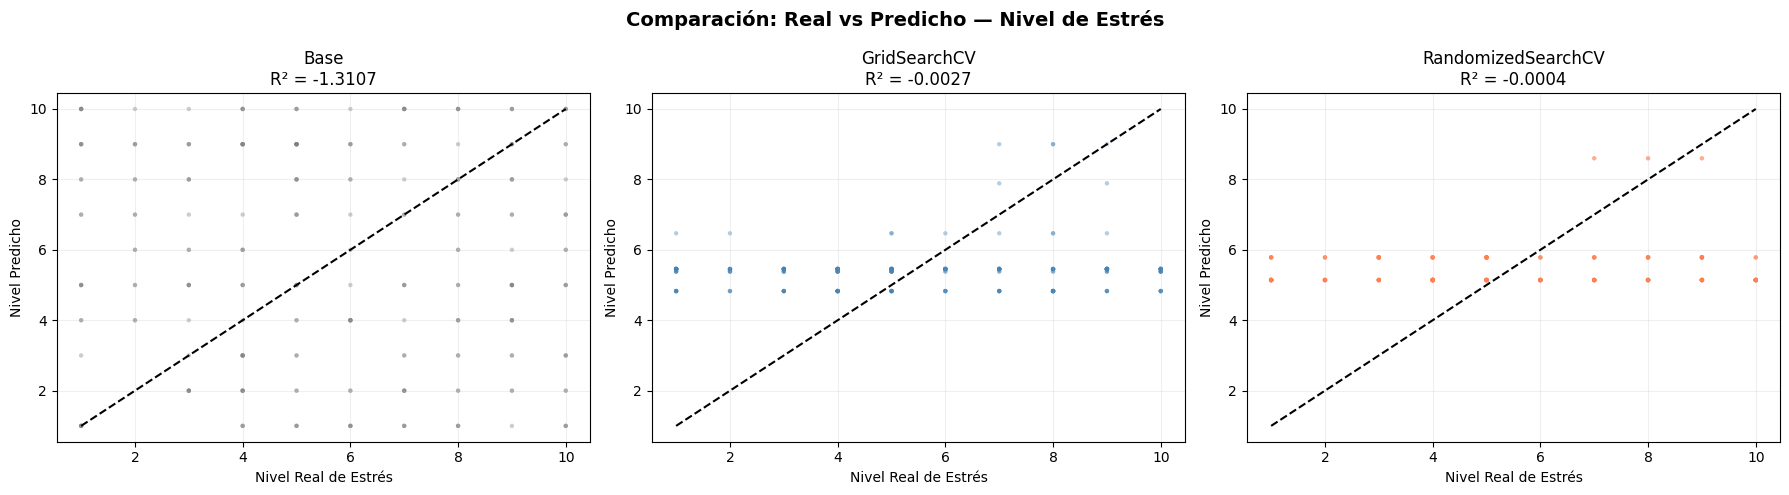

In [ ]:
# ── Real vs Predicho para los 3 modelos lado a lado ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [y_pred_base,   y_pred_grid,    y_pred_random]
titulos = ['Base',         'GridSearchCV', 'RandomizedSearchCV']
colores = ['gray',         'steelblue',    'coral']

for ax, pred, titulo, color in zip(axes, modelos, titulos, colores):
    r2 = r2_score(y_test, pred)
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=10, edgecolors='none')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', linewidth=1.5)
    ax.set_xlabel('Nivel Real de Estrés')
    ax.set_ylabel('Nivel Predicho')
    ax.set_title(f'{titulo}\nR² = {r2:.4f}')
    ax.grid(True, alpha=0.2)

plt.suptitle('Comparación: Real vs Predicho — Nivel de Estrés',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎨 23. Árbol optimizado con paleta de colores (RdYlGn)

/tmp/ipykernel_4589/2423437437.py:51: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4589/2423437437.py:51: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4589/2423437437.py:51: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

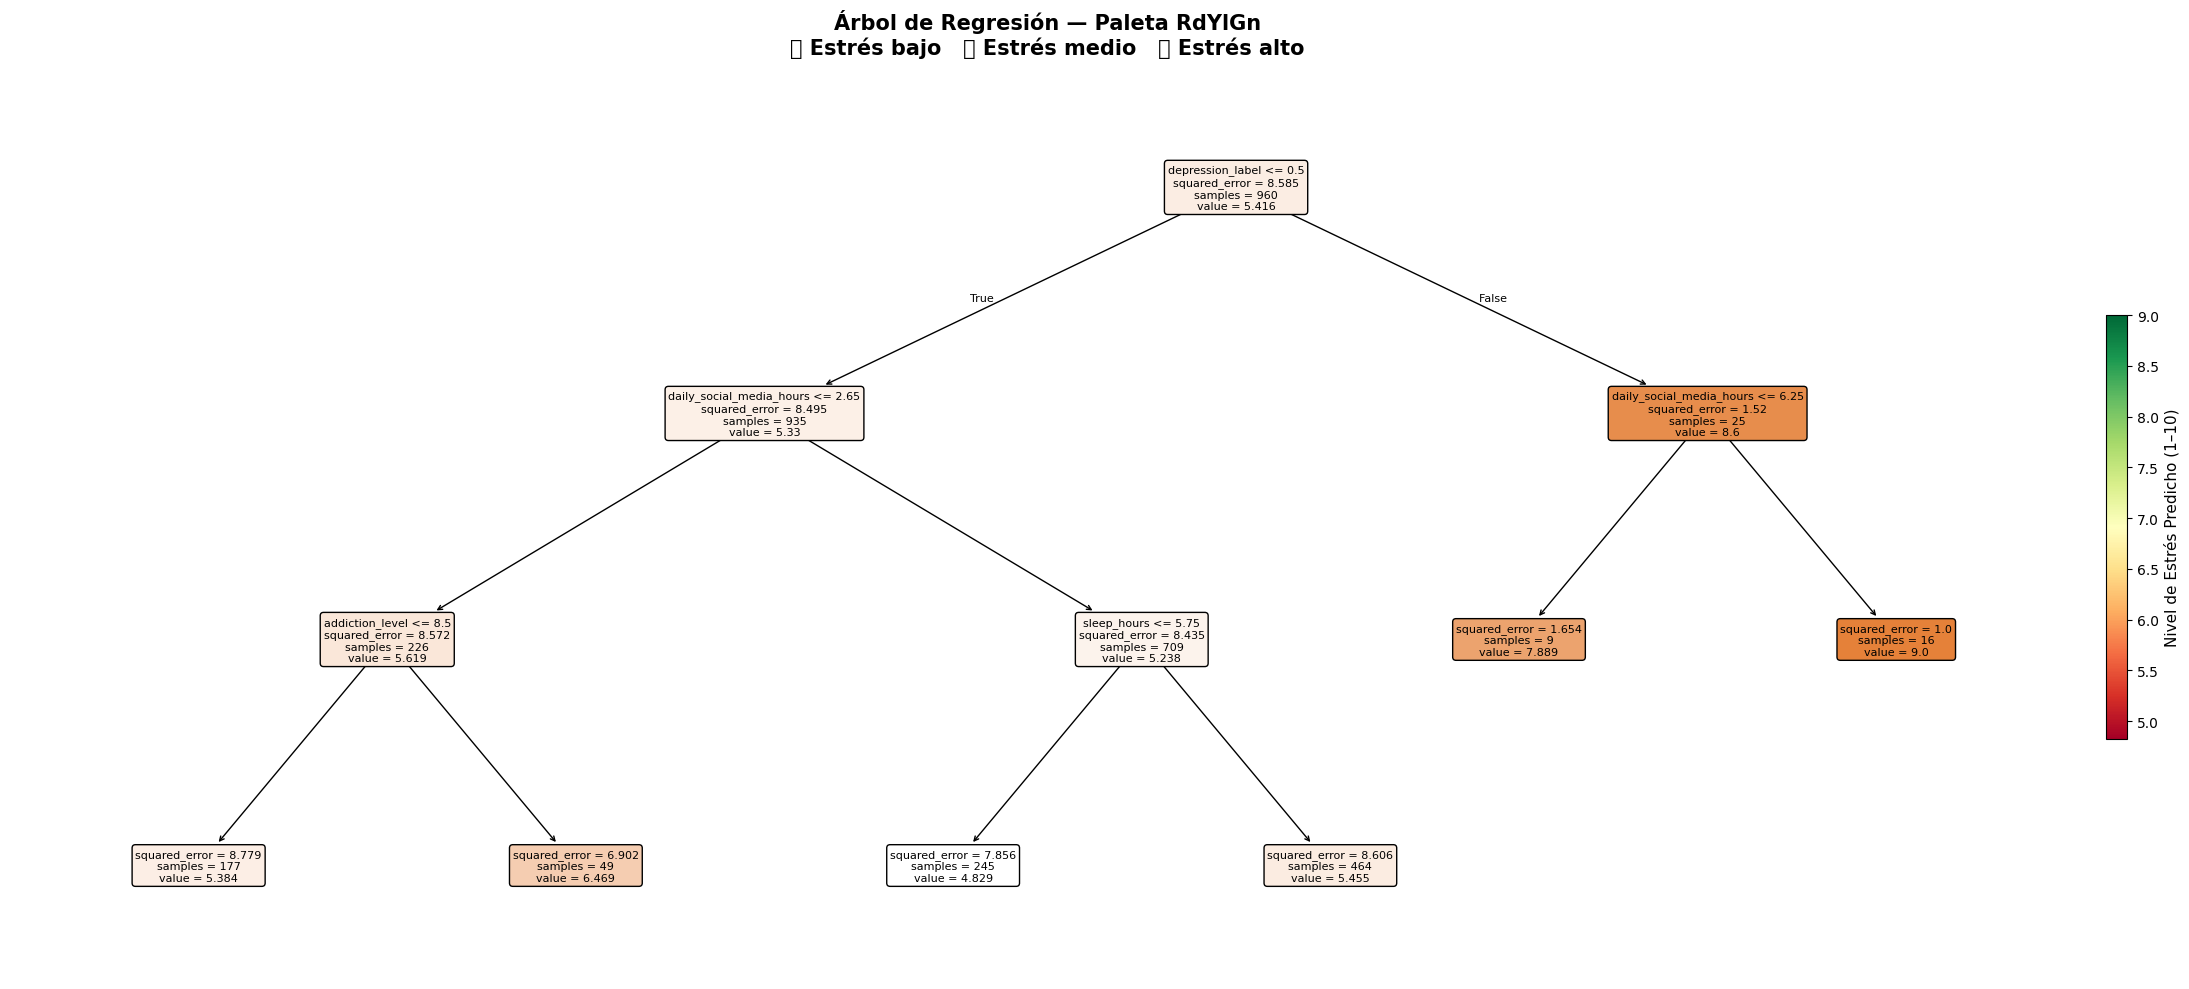

In [ ]:
# ── Árbol coloreado: rojo = estrés bajo, amarillo = medio, verde = alto ───────
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.tree import export_graphviz

fig, ax = plt.subplots(figsize=(22, 10))

artistas = plot_tree(
    mejor_grid,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    precision=3
)

# ── Colorear cada nodo según el valor predicho ───────────────────────────────
tree_ = mejor_grid.tree_
valores = tree_.value[:, 0, 0]   # valor promedio de cada nodo

colormap = plt.cm.RdYlGn
norm     = Normalize(vmin=valores.min(), vmax=valores.max())
n_nodes  = tree_.node_count

nodo_idx = 0
for artist in artistas:
    if hasattr(artist, 'get_facecolor'):
        color = colormap(norm(valores[nodo_idx]))
        artist.set_facecolor(color)
        artist.set_edgecolor('black')
        artist.set_linewidth(0.8)
        nodo_idx += 1
        if nodo_idx >= n_nodes:
            break

# ── Barra de color como leyenda ───────────────────────────────────────────────
sm = ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.01, pad=0.01, shrink=0.6)
cbar.set_label('Nivel de Estrés Predicho (1–10)', fontsize=11)

ax.set_title(
    'Árbol de Regresión — Paleta RdYlGn\n'
    '🔴 Estrés bajo   🟡 Estrés medio   🟢 Estrés alto',
    fontsize=15, fontweight='bold', pad=15
)

plt.tight_layout()
plt.show()

## 🌲 24. Árbol simplificado (3 niveles) — alta legibilidad

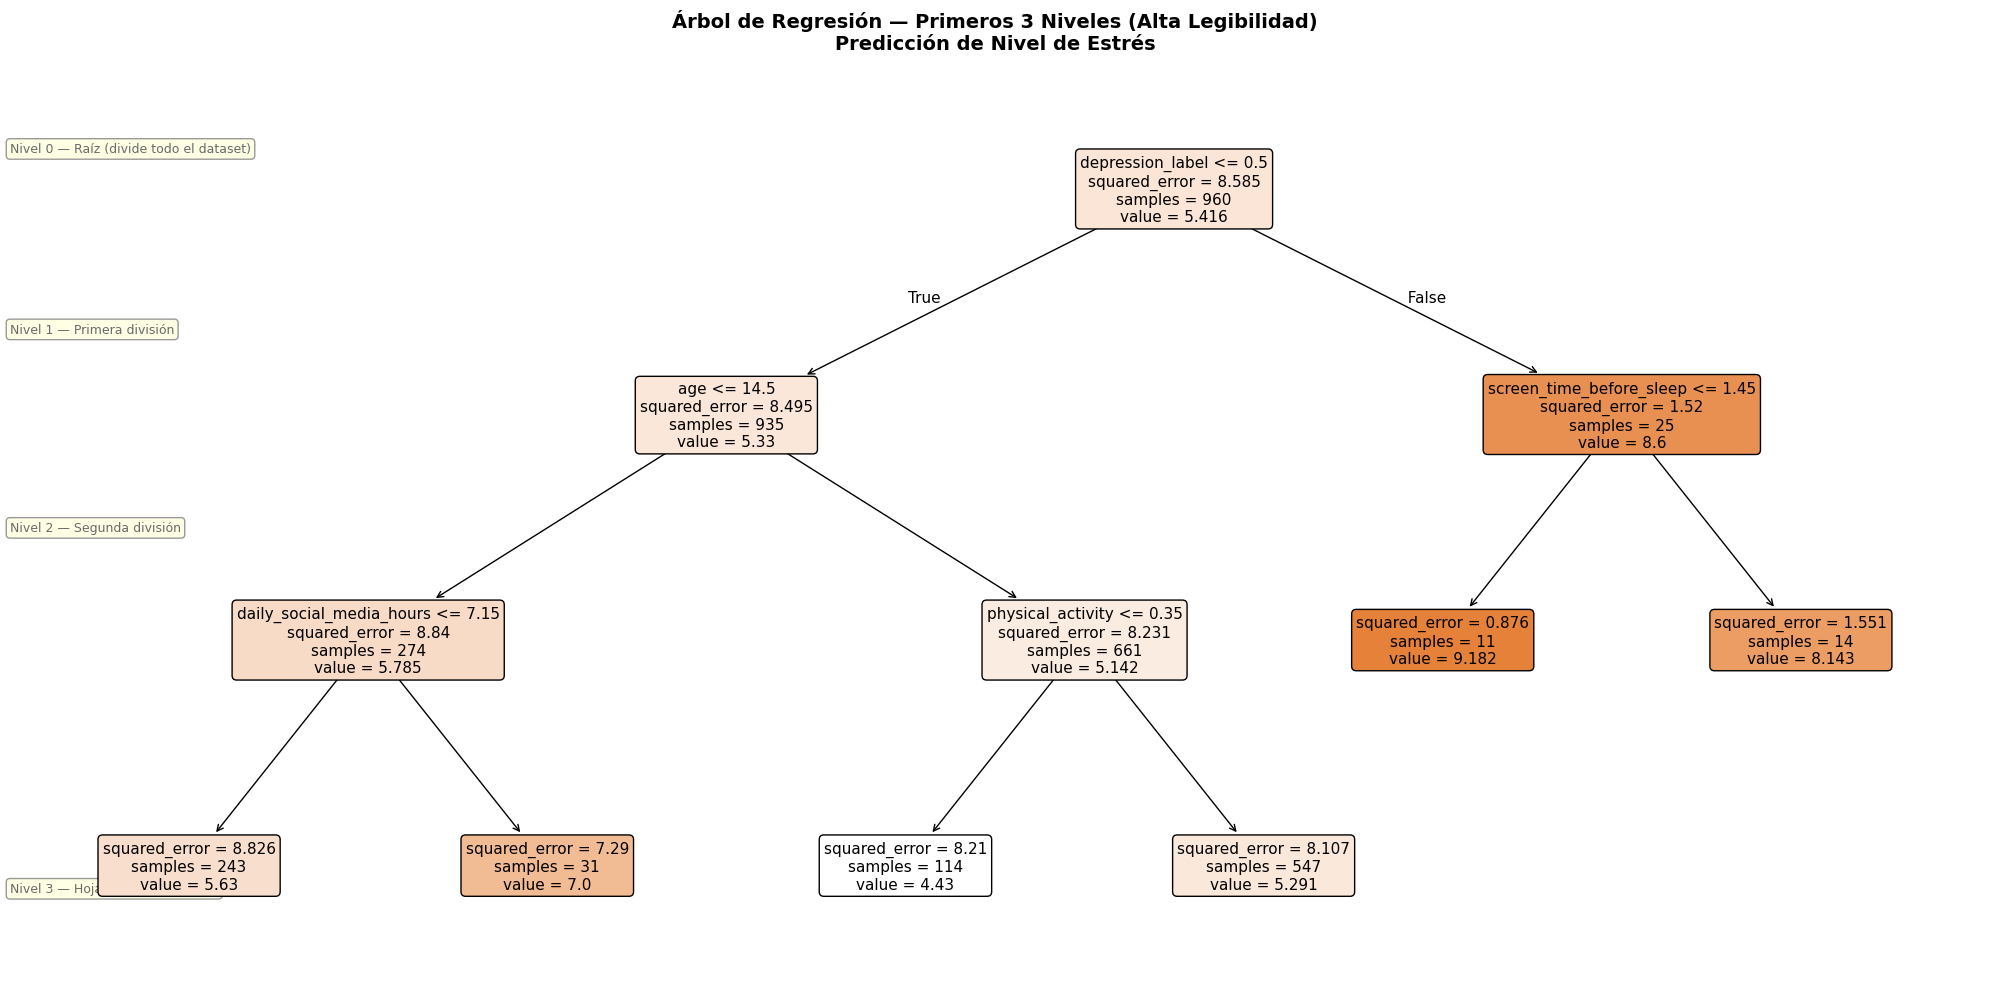

In [ ]:
# ── Cuando el árbol es profundo, los nodos se vuelven ilegibles ───────────────
# Solución: crear un árbol SOLO para visualización con max_depth=3
# El modelo real sigue siendo el optimizado; este es solo para mostrar

arbol_visual = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=3,           # ← solo 3 niveles para visualizar
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
arbol_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    arbol_visual,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=11,
    precision=3,
    ax=ax,
    impurity=True,
    proportion=False
)

# ── Anotar cada nivel del árbol ───────────────────────────────────────────────
niveles = {
    0.92: 'Nivel 0 — Raíz (divide todo el dataset)',
    0.72: 'Nivel 1 — Primera división',
    0.50: 'Nivel 2 — Segunda división',
    0.10: 'Nivel 3 — Hojas (predicción final)'
}

for y_pos, texto in niveles.items():
    ax.annotate(
        texto,
        xy=(0, y_pos), xycoords='axes fraction',
        fontsize=9, color='dimgray',
        ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8)
    )

ax.set_title(
    'Árbol de Regresión — Primeros 3 Niveles (Alta Legibilidad)\nPredicción de Nivel de Estrés',
    fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()
plt.show()

## 🥧 25. Importancia de características con gráfico de torta

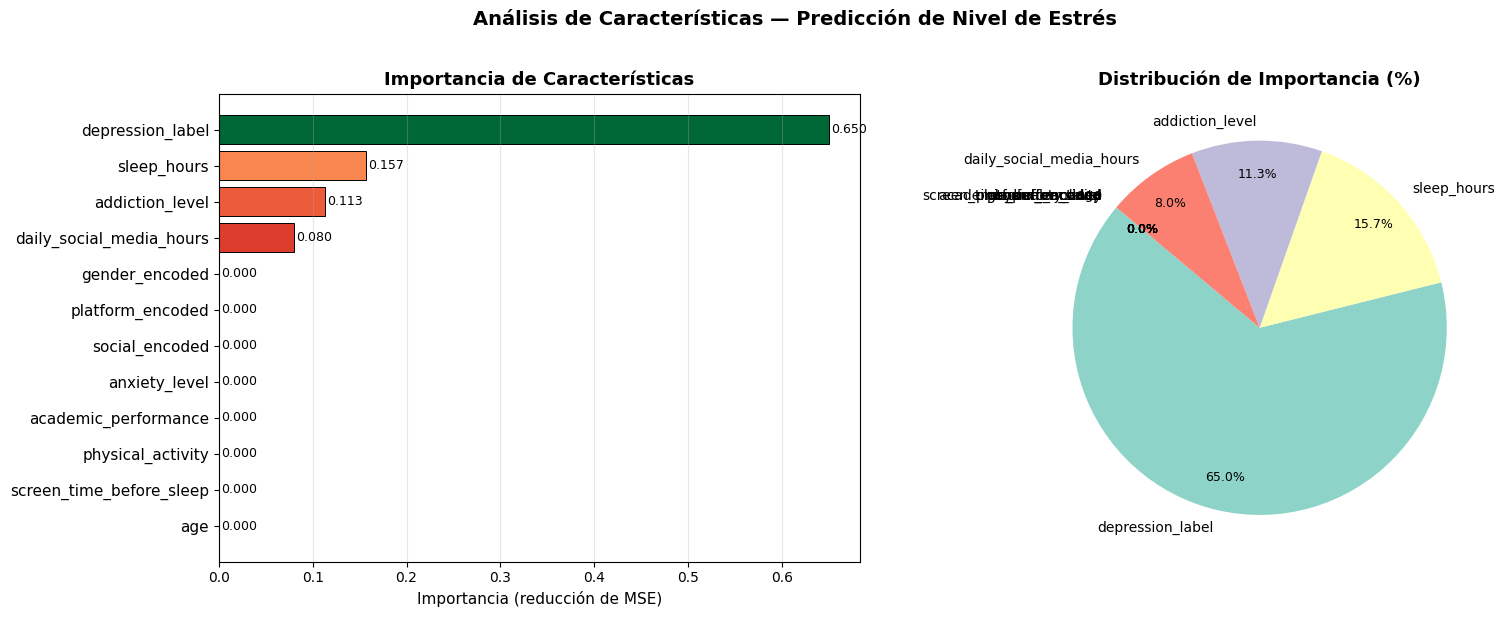

In [ ]:
# ── Importancia con barras horizontales + gráfico de torta ──────────────────
importancias = mejor_grid.feature_importances_
indices      = np.argsort(importancias)[::-1]   # ordenar de mayor a menor
nombres      = np.array(X.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Barras horizontales ───────────────────────────────────────────────────────
colores_imp = plt.cm.RdYlGn(importancias[indices] / importancias.max())

axes[0].barh(
    range(len(indices)),
    importancias[indices],
    color=colores_imp,
    edgecolor='black',
    linewidth=0.7
)
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels(nombres[indices], fontsize=11)
axes[0].set_xlabel('Importancia (reducción de MSE)', fontsize=11)
axes[0].set_title('Importancia de Características', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, axis='x', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(importancias[indices]):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# ── Gráfico de torta ──────────────────────────────────────────────────────────
colores_pie = plt.cm.Set3(np.linspace(0, 1, len(indices)))
wedges, texts, autotexts = axes[1].pie(
    importancias[indices],
    labels=nombres[indices],
    autopct='%1.1f%%',
    colors=colores_pie,
    startangle=140,
    pctdistance=0.82
)
for text in autotexts:
    text.set_fontsize(9)
axes[1].set_title('Distribución de Importancia (%)', fontsize=13, fontweight='bold')

plt.suptitle('Análisis de Características — Predicción de Nivel de Estrés',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()